In [66]:
import pandas as pd
df = pd.read_csv('diabetes.csv')

In [67]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [68]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: ylabel='BMI'>

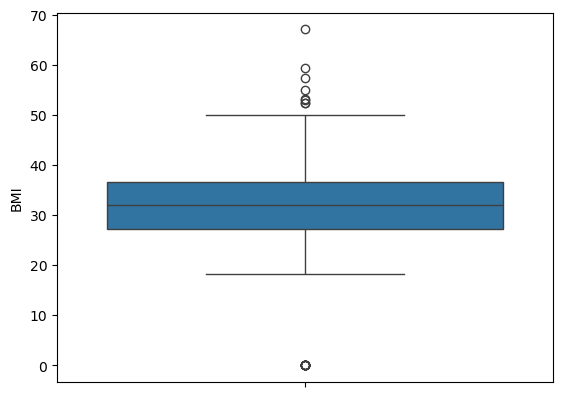

In [69]:
import seaborn as sns
sns.boxplot(df['BMI'])

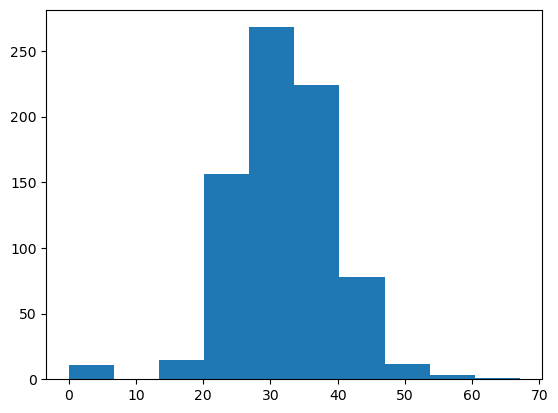

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(df['BMI'])
plt.show()

In [71]:
X = df.drop(columns=['Outcome'])
Y = df['Outcome']

In [72]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
SS = StandardScaler()

In [75]:
X_count_SS = SS.fit_transform(X)

In [76]:
X_count_SS = pd.DataFrame(X_count_SS)

In [77]:
X_count_SS.columns = list(X)

In [78]:
X_count_SS.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [79]:
X = X_count_SS

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.30)

In [81]:
from sklearn.svm import SVC

In [82]:
model = SVC(kernel='poly',degree=3)
model.fit(X_train.values,Y_train)
Y_pred_train = model.predict(X_train.values)
Y_pred_test = model.predict(X_test.values)

In [83]:
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(Y_train,Y_pred_train)
print('Training accuracy score :',ac1)
ac2 = accuracy_score(Y_test,Y_pred_test)
print('Test accuracy score :',ac2)

Training accuracy score : 0.8063314711359404
Test accuracy score : 0.7359307359307359


In [84]:
!pip install mlxtend

In [85]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

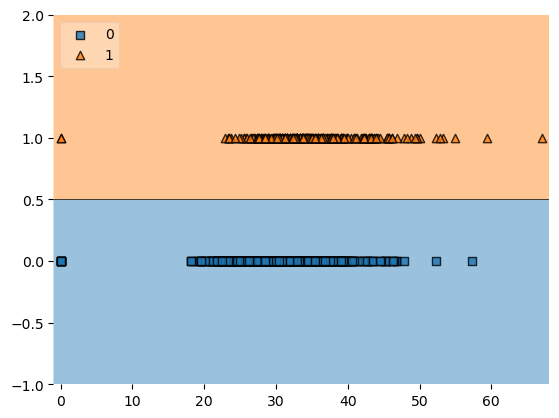

In [88]:
X_plot = df[['BMI', 'Outcome']].values 
Y = df['Outcome'].values               
model = SVC(kernel='linear')
model.fit(X_plot, Y)
plot_decision_regions(X=X_plot, y=Y, clf=model, legend=2)